<a href="https://colab.research.google.com/github/ranjeet4651/Data-Analysis/blob/main/US_Honey_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/US_honey_dataset.csv')

In [3]:
df.head()

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.0,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.0,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.0,1920000,1995
3,3,California,420000,93,39060000,4687000,60.0,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.0,1836000,1995


# **EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1115 non-null   int64  
 1   state                1115 non-null   object 
 2   colonies_number      1115 non-null   int64  
 3   yield_per_colony     1115 non-null   int64  
 4   production           1115 non-null   int64  
 5   stocks               1115 non-null   int64  
 6   average_price        1115 non-null   float64
 7   value_of_production  1115 non-null   int64  
 8   year                 1115 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 78.5+ KB


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
state,0
colonies_number,0
yield_per_colony,0
production,0
stocks,0
average_price,0
value_of_production,0
year,0


In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

# 1. Which state is having the highest honey production throught out all these years?

In [8]:
df1 = df.groupby('state')['production'].sum().sort_values(ascending=False).reset_index()

In [9]:
df1

,state,production
0,NorthDakota,513742000
1,California,423876000
2,SouthDakota,355726000
3,Florida,280934000
4,Montana,197173000
5,Minnesota,176581000
6,Texas,129441000
7,Michigan,101063000
8,Wisconsin,99909000
9,Idaho,87188000


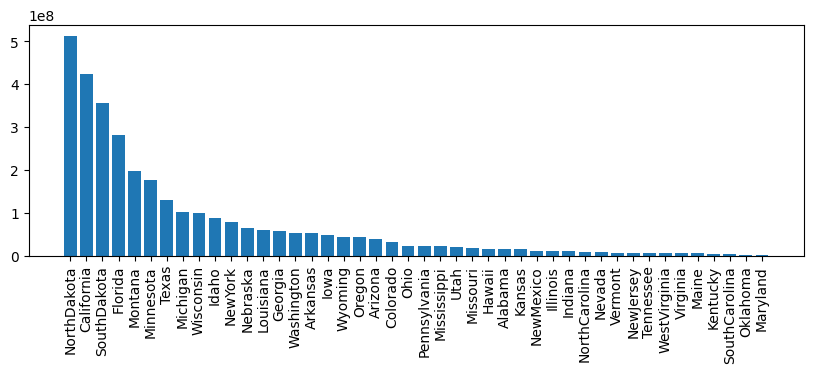

In [10]:
plt.figure(figsize=(10,3))
plt.bar(df1['state'],df1['production'])
plt.xticks(rotation=90)
plt.show()

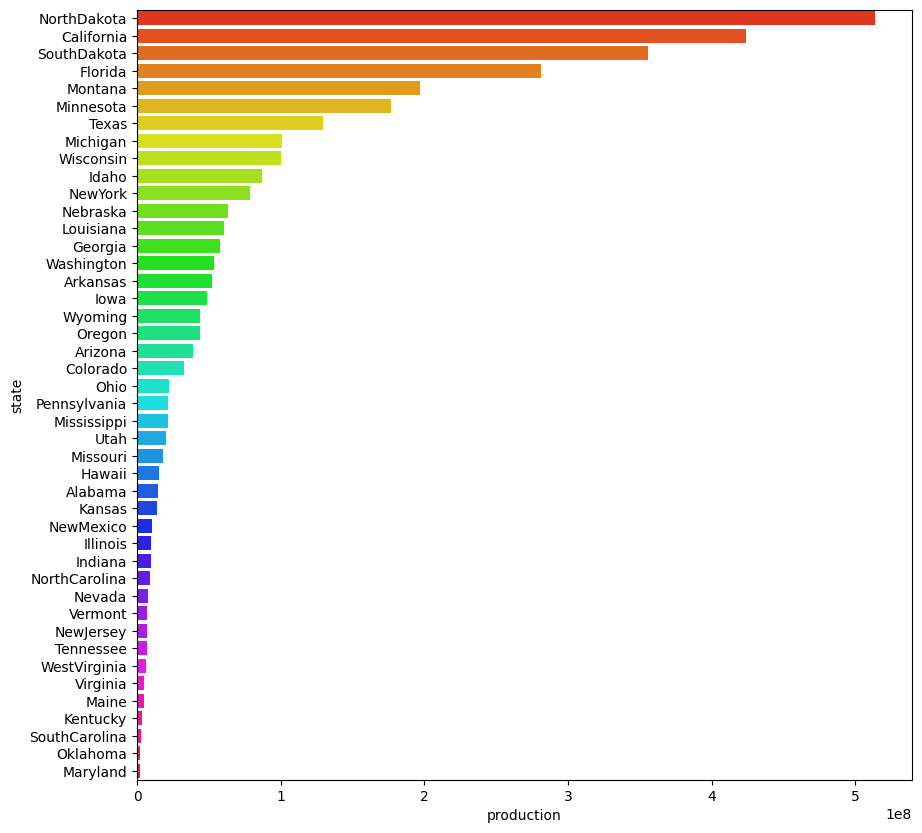

In [11]:
plt.figure(figsize=(10,10))
sns.barplot(data=df1,x='production',y='state', palette='hsv')
plt.show()

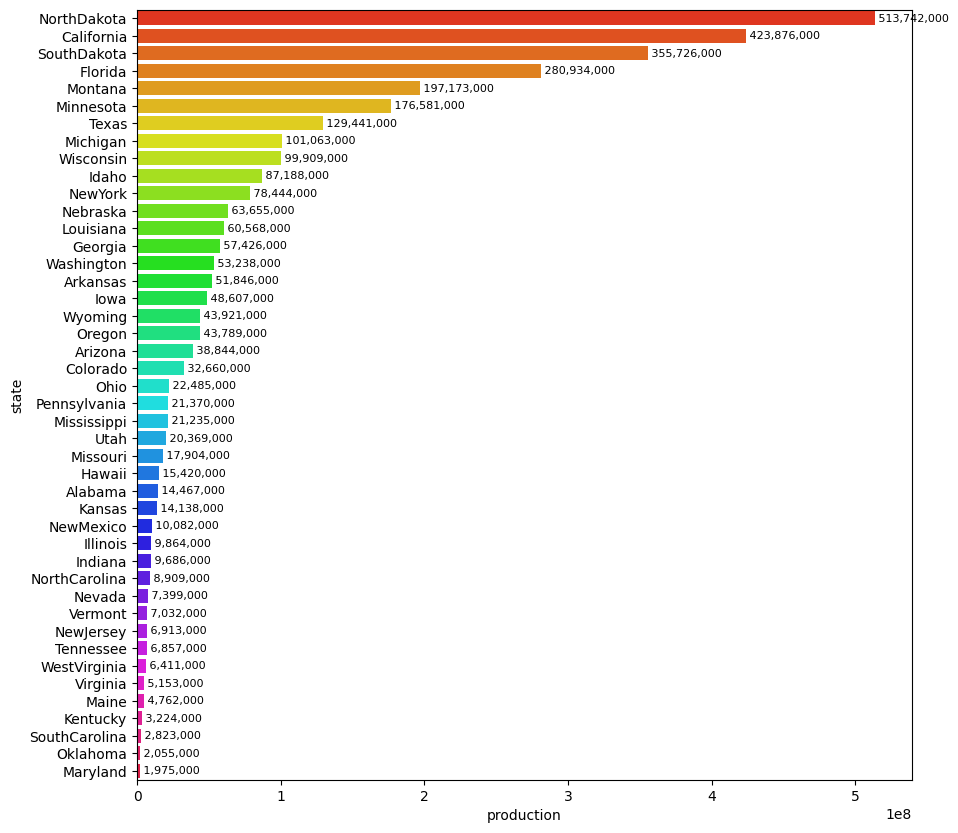

In [12]:
plt.figure(figsize=(10,10))
sns.barplot(data=df1,x='production',y='state', palette='hsv')
for index, value in enumerate(df1['production']):
  plt.text(value +100, index, f'{value : ,}', va='center',fontsize=8)
plt.show()

+ North Dakota : longest bar -> highest total production.
+ Maryland: lowest bar -> minimum

# 2. which state is having the highest and the lowest yield per colony

In [13]:
df2 = df.groupby('state')['yield_per_colony'].mean().sort_values(ascending=False).reset_index()

In [14]:
df2.head()

,state,yield_per_colony
0,Hawaii,103.777778
1,Louisiana,92.814815
2,Mississippi,86.703704
3,NorthDakota,83.925926
4,Montana,79.555556


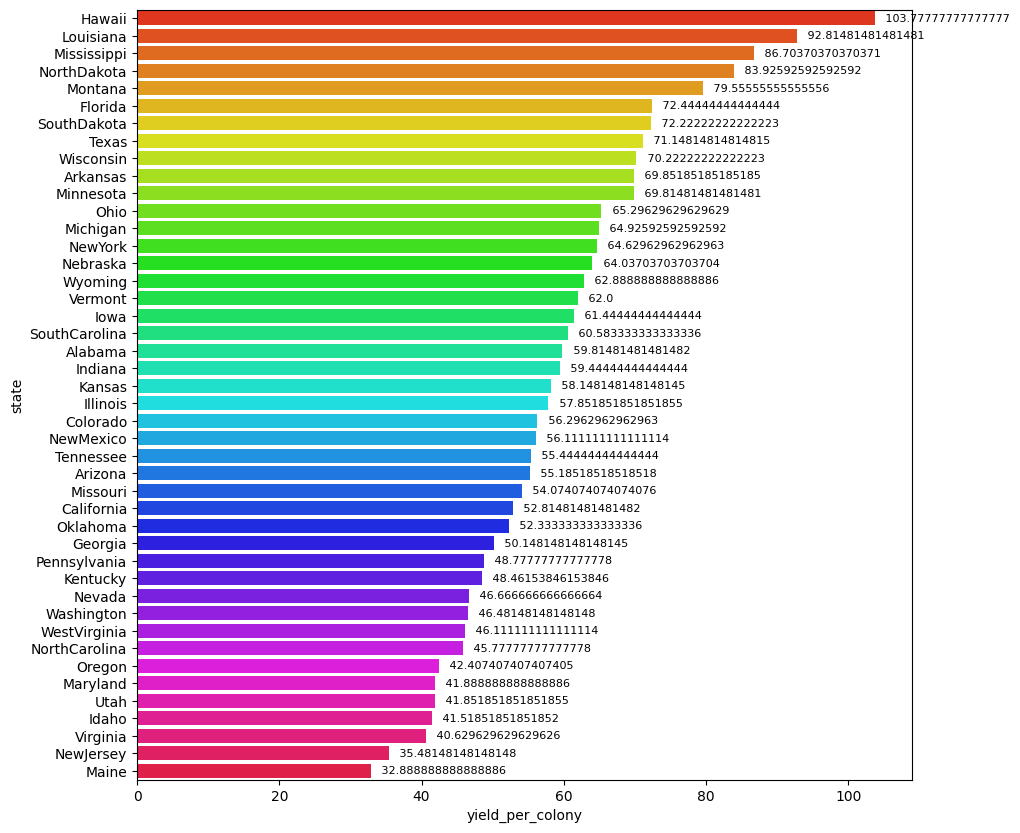

In [15]:
plt.figure(figsize=(10,10))
sns.barplot(data=df2,x='yield_per_colony',y='state', palette='hsv')
for index, value in enumerate(df2['yield_per_colony']):
  plt.text(value +1, index, f'{value : ,}', va='center',fontsize=8)
plt.show()

# 3. Which year witnessed the highest profit in the honey production